# ДЗ №3 — Исследование KNN (k-Nearest Neighbors)

**Датасет:** Breast Cancer Wisconsin (Diagnostic), тот же, что и в HW02.  
**Kaggle:** https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data  

**Задача:** бинарная классификация — предсказать `diagnosis`: **M** (malignant) / **B** (benign) по числовым признакам.

*Ограничение курса:* решение оформлено самостоятельно с опорой на документацию sklearn/pandas и материалы лекций; фрагменты структуры ноутбука могли обсуждаться вне кода.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42

## 1. Выбор датасета

Используем **Breast Cancer Wisconsin**: много **числовых** признаков, **2 класса**, разумно использовать **расстояния** между объектами (KNN). Размер ~569 строк — небольшой/средний объём для учебного проекта.

In [2]:
import pandas as pd

df = pd.read_csv("/Users/Chamomile/Desktop/ml-famcs-homeworks/hw02_eda/data.csv")

In [3]:
df = df.drop(columns=["Unnamed: 32"], errors="ignore")

X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"]

le = LabelEncoder()
y_enc = le.fit_transform(y)   

print("Классы:", le.classes_)
print("X shape:", X.shape)

Классы: ['B' 'M']
X shape: (569, 30)


## 2. Первичный анализ данных

Кратко: размер, типы, пропуски, баланс классов, возможные проблемы.

In [4]:
print("Размер:", df.shape)
print("\nТипы:\n", df.dtypes.value_counts())
print("\nПропуски по столбцам:\n", df.isnull().sum().sort_values(ascending=False).head(10))
print("\nРаспределение классов:\n", df["diagnosis"].value_counts())
print("\nДоля:\n", df["diagnosis"].value_counts(normalize=True))

display(df.describe().T.head(10))   # если display недоступен — df.describe().T.head(10)

Размер: (569, 32)

Типы:
 float64    30
int64       1
str         1
Name: count, dtype: int64

Пропуски по столбцам:
 id                      0
diagnosis               0
symmetry_worst          0
concave points_worst    0
concavity_worst         0
compactness_worst       0
smoothness_worst        0
area_worst              0
perimeter_worst         0
texture_worst           0
dtype: int64

Распределение классов:
 diagnosis
B    357
M    212
Name: count, dtype: int64

Доля:
 diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.00000,869218.00000,906024.00000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.98100,11.70000,13.37000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.71000,16.17000,18.84000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.79000,75.17000,86.24000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.50000,420.30000,551.10000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.05263,0.08637,0.09587,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.01938,0.06492,0.09263,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.00000,0.02956,0.06154,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.00000,0.02031,0.03350,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.10600,0.16190,0.17920,1.957000e-01,3.040000e-01


Классы слегка несбалансированы; после удаления **Unnamed: 32** пропусков в признаках нет; все признаки для модели числовые; **id** не используем как признак.

In [14]:
df = df.drop(columns=["Unnamed: 32"], errors="ignore")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

## 3. Подготовка данных

- Пропуски: в чистых данных после удаления служебной колонки **нет**; при необходимости можно было бы использовать `SimpleImputer` в `Pipeline`.
- Категориальная цель `diagnosis` закодирована в **числа** (`LabelEncoder`).
- **Масштабирование** (`StandardScaler`) важно для **KNN**: расстояние чувствительно к масштабу признаков; без масштаба признак с большим разбросом «перетянет» расстояние.
- **Train/test split:** параметры подбираем только по **train** (и кросс-валидации на train), финальная честная оценка — на **test**. Подбирать гиперпараметры на **test** нельзя — это **утечка информации** и завышенная оценка качества на новых данных.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.25, random_state=RANDOM_STATE, stratify=y_enc
)
print(X_train.shape, X_test.shape)

(426, 30) (143, 30)


## 4. Обучение KNN и влияние параметров

Проверим:
- число соседей `n_neighbors`,
- веса `uniform` / `distance`,
- метрики расстояния: **Manhattan** (`p=1`), **Euclidean** (`p=2`) в рамках **Minkowski** у `KNeighborsClassifier`.

In [15]:
from sklearn.neighbors import KNeighborsClassifier

help(KNeighborsClassifier)

Help on class KNeighborsClassifier in module sklearn.neighbors._classification:

class KNeighborsClassifier(sklearn.neighbors._base.KNeighborsMixin, sklearn.base.ClassifierMixin, sklearn.neighbors._base.NeighborsBase)
 |  KNeighborsClassifier(n_neighbors=5, *, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski', metric_params=None, n_jobs=None)
 |  
 |  Classifier implementing the k-nearest neighbors vote.
 |  
 |  Read more in the :ref:`User Guide <classification>`.
 |  
 |  Parameters
 |  ----------
 |  n_neighbors : int, default=5
 |      Number of neighbors to use by default for :meth:`kneighbors` queries.
 |  
 |  weights : {'uniform', 'distance'}, callable or None, default='uniform'
 |      Weight function used in prediction.  Possible values:
 |  
 |      - 'uniform' : uniform weights.  All points in each neighborhood
 |        are weighted equally.
 |      - 'distance' : weight points by the inverse of their distance.
 |        in this case, closer neighb

In [6]:
knn_raw = KNeighborsClassifier(n_neighbors=5, weights="uniform", metric="minkowski", p=2)
knn_raw.fit(X_train, y_train)
y_pred_raw = knn_raw.predict(X_test)
print("KNN без scaler, accuracy:", accuracy_score(y_test, y_pred_raw))

KNN без scaler, accuracy: 0.9230769230769231


In [7]:
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5, weights="uniform", metric="minkowski", p=2)),
])
pipe_knn.fit(X_train, y_train)
y_pred_scaled = pipe_knn.predict(X_test)
print("KNN + StandardScaler, accuracy:", accuracy_score(y_test, y_pred_scaled))

KNN + StandardScaler, accuracy: 0.958041958041958


In [8]:
results = []
for k in [1, 3, 5, 7, 9, 11, 15, 21]:
    for weights in ["uniform", "distance"]:
        for p in [1, 2]:   # 1=Manhattan, 2=Euclidean (Minkowski)
            clf = Pipeline([
                ("scaler", StandardScaler()),
                ("knn", KNeighborsClassifier(n_neighbors=k, weights=weights, metric="minkowski", p=p)),
            ])
            clf.fit(X_train, y_train)
            acc = accuracy_score(y_test, clf.predict(X_test))
            results.append({"k": k, "weights": weights, "p": p, "accuracy": acc})

res_df = pd.DataFrame(results).sort_values("accuracy", ascending=False)
res_df.head(12)

,k,weights,p,accuracy
16,9,uniform,1,0.972028
6,3,distance,1,0.972028
18,9,distance,1,0.972028
15,7,distance,2,0.972028
13,7,uniform,2,0.972028
8,5,uniform,1,0.972028
10,5,distance,1,0.972028
4,3,uniform,1,0.972028
27,15,distance,2,0.965035
25,15,uniform,2,0.965035


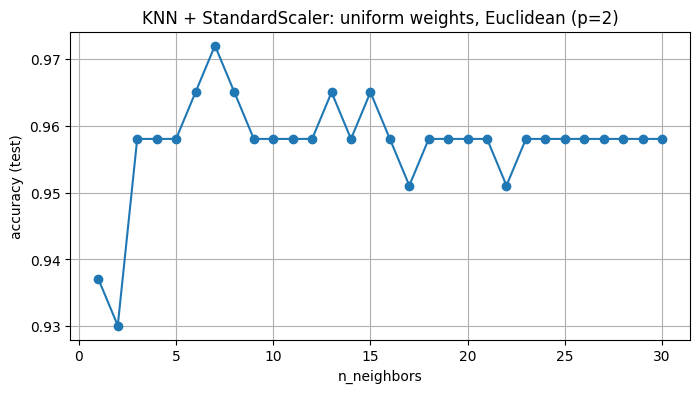

In [9]:
ks = list(range(1, 31))
acc_uni_euclid = []
for k in ks:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k, weights="uniform", metric="minkowski", p=2)),
    ])
    model.fit(X_train, y_train)
    acc_uni_euclid.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.plot(ks, acc_uni_euclid, marker="o")
plt.xlabel("n_neighbors")
plt.ylabel("accuracy (test)")
plt.title("KNN + StandardScaler: uniform weights, Euclidean (p=2)")
plt.grid(True)
plt.show()

## 5. Подбор гиперпараметров (кросс-валидация)

Используем `GridSearchCV` с `Pipeline` (scaler + KNN). Подбор только на **обучающей** части, стратифицированные фолды.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grid = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],
    "knn__metric": ["minkowski"],
}

grid_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier()),
])

grid = GridSearchCV(
    grid_pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
)
grid.fit(X_train, y_train)

print("Лучшие параметры:", grid.best_params_)
print("Лучший CV accuracy:", grid.best_score_)

best_knn = grid.best_estimator_
y_pred_best = best_knn.predict(X_test)
print("Test accuracy (лучший KNN из grid):", accuracy_score(y_test, y_pred_best))
print("\nОтчёт:\n", classification_report(y_test, y_pred_best, target_names=le.classes_))

Лучшие параметры: {'knn__metric': 'minkowski', 'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'uniform'}
Лучший CV accuracy: 0.9718194254445965
Test accuracy (лучший KNN из grid): 0.972027972027972

Отчёт:
               precision    recall  f1-score   support

           B       0.96      1.00      0.98        90
           M       1.00      0.92      0.96        53

    accuracy                           0.97       143
   macro avg       0.98      0.96      0.97       143
weighted avg       0.97      0.97      0.97       143



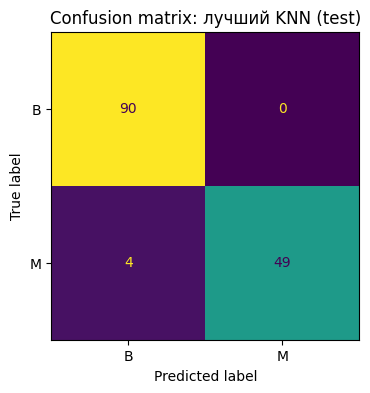

In [11]:
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, display_labels=le.classes_, ax=ax, colorbar=False)
plt.title("Confusion matrix: лучший KNN (test)")
plt.show()

## Сравнение KNN с базовыми моделями

Сравним лучший KNN из `GridSearchCV` с **логистической регрессией** и **Random Forest** на тех же train/test и со scaler там, где это уместно.

In [12]:
log_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
])
log_pipe.fit(X_train, y_train)
y_pred_log = log_pipe.predict(X_test)

rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced")
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

def report(name, y_true, y_pred):
    print(f"{name}")
    print("accuracy:", accuracy_score(y_true, y_pred))
    print("precision:", precision_score(y_true, y_pred))
    print("recall:", recall_score(y_true, y_pred))
    print("f1:", f1_score(y_true, y_pred))
    print()

report("Лучший KNN (test)", y_test, y_pred_best)
report("LogisticRegression + scaler (test)", y_test, y_pred_log)
report("RandomForest (test)", y_test, y_pred_rf)

Лучший KNN (test)
accuracy: 0.972027972027972
precision: 1.0
recall: 0.9245283018867925
f1: 0.9607843137254902

LogisticRegression + scaler (test)
accuracy: 0.965034965034965
precision: 0.98
recall: 0.9245283018867925
f1: 0.9514563106796117

RandomForest (test)
accuracy: 0.972027972027972
precision: 1.0
recall: 0.9245283018867925
f1: 0.9607843137254902



## Кросс-валидация на train (для сравнения моделей)

Сравним среднюю accuracy по 5 фолдам **на train-данных** 

In [13]:
for name, est in [
    ("KNN best", grid.best_estimator_),
    ("LogReg", log_pipe),
    ("RandomForest", rf),
]:
    scores = cross_val_score(est, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    print(name, "CV accuracy mean ± std:", scores.mean().round(4), "±", scores.std().round(4))

KNN best CV accuracy mean ± std: 0.9718 ± 0.0058
LogReg CV accuracy mean ± std: 0.9718 ± 0.016
RandomForest CV accuracy mean ± std: 0.96 ± 0.0206


## Итоги и интерпретация

1. **Масштабирование:** KNN на отмасштабированных признаках обычно даёт **лучше** качество, чем на сырых, из-за сопоставимых вкладов признаков в расстояние.
2. **k:** слишком маленькое **k** → чувствительность к шуму; слишком большое → сглаживание границы и риск смещения; оптимум виден по кривой и по `GridSearchCV`.
3. **Метрика расстояния:** Manhattan vs Euclidean может по-разному учитывать «рёбра» в пространстве признаков; на этом датасете сравниваем по CV/test.
4. **Ограничения KNN:** дорогой **predict** на больших данных (нужно искать соседей); чувствительность к **проклятию размерности** при очень большом числе признаков; важна **однородность масштаба** признаков.
5. **Сравнение с другими моделями:** логистическая регрессия даёт интерпретируемую линейную границу; RandomForest — нелинейности без явного расстояния; KNN — локальная геометрия в пространстве признаков.

**Честность валидации:** гиперпараметры KNN подбирались через `GridSearchCV` **только на train**; отдельный **test** использован для финальной оценки и матрицы ошибок.